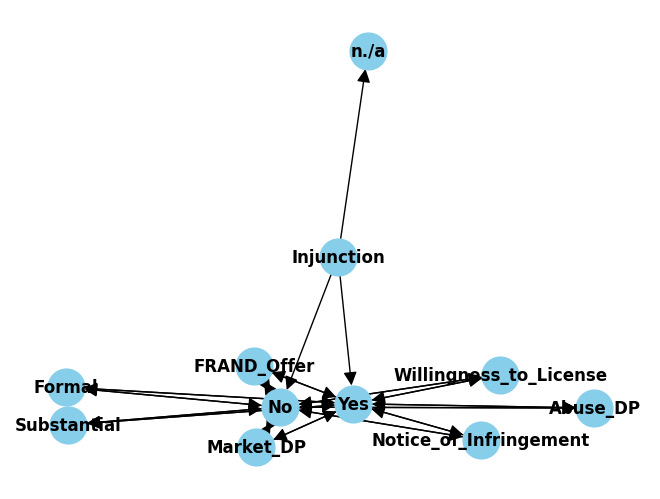

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Read your CSV file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')


# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges based on the decision tree structure
edges = [
    ('Injunction', 'Yes'), ('Injunction', 'No'), ('Injunction', 'n./a'),
    ('Yes', 'Market_DP'), ('No', 'Market_DP'), ('Market_DP', 'Yes'), ('Market_DP', 'No'),
    ('Yes', 'Abuse_DP'), ('No', 'Abuse_DP'), ('Abuse_DP', 'Yes'), ('Abuse_DP', 'No'),
    ('Yes', 'Notice_of_Infringement'), ('No', 'Notice_of_Infringement'), ('Notice_of_Infringement', 'Yes'), ('Notice_of_Infringement', 'No'),
    ('Yes', 'Willingness_to_License'), ('No', 'Willingness_to_License'), ('Willingness_to_License', 'Yes'), ('Willingness_to_License', 'No'),
    ('Yes', 'FRAND_Offer'), ('No', 'FRAND_Offer'), ('FRAND_Offer', 'Yes'), ('FRAND_Offer', 'No'),
    ('Yes', 'Formal'), ('No', 'Formal'), ('Formal', 'Yes'), ('Formal', 'No'),
    ('Yes', 'Substantial'), ('No', 'Substantial'), ('Substantial', 'Yes'), ('Substantial', 'No'),
]

G.add_edges_from(edges)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, node_color='skyblue', font_color='black', arrowsize=20)

plt.show()


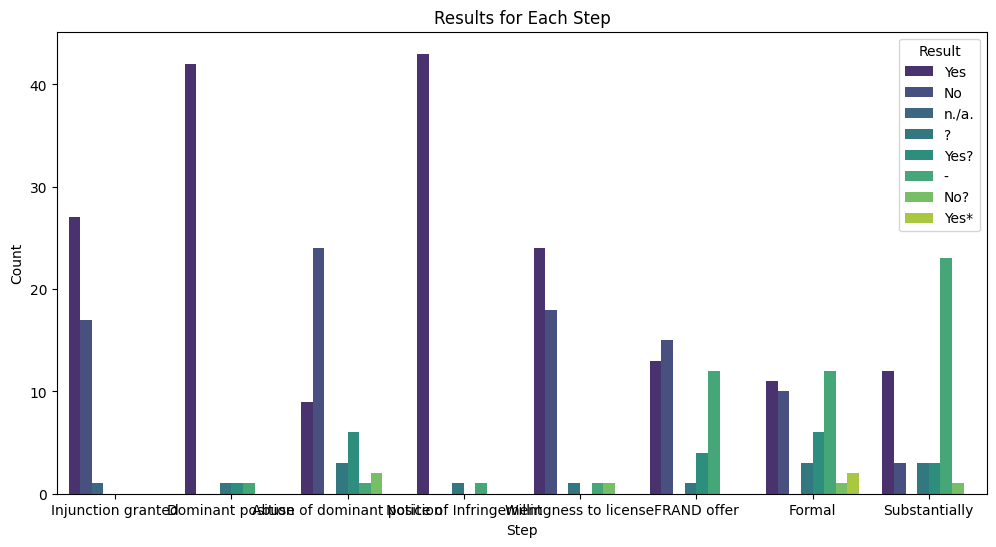

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read your Excel file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')

# Extract relevant columns for visualization
relevant_columns = ['Entscheidung (Untrelassung)', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']

# Subset the DataFrame with relevant columns
df_relevant = df[relevant_columns]
df_relevant = df_relevant.rename(columns={'Entscheidung (Untrelassung)' : 'Injunction granted'})

# Convert 'Yes' to 1, 'No' to 0, and treat other values as 0
# df_relevant.replace({'Yes': 1, 'No': 0, 'Yes?': 1, '-': 0}, inplace=True)

# Create a bar plot with separate categories for 'Yes', 'No', and '-'
plt.figure(figsize=(12, 6))
sns.countplot(data=df_relevant.melt(var_name='Step', value_name='Result'), x='Step', hue='Result', palette='viridis')
plt.title('Results for Each Step')
plt.ylabel('Count')
plt.show()


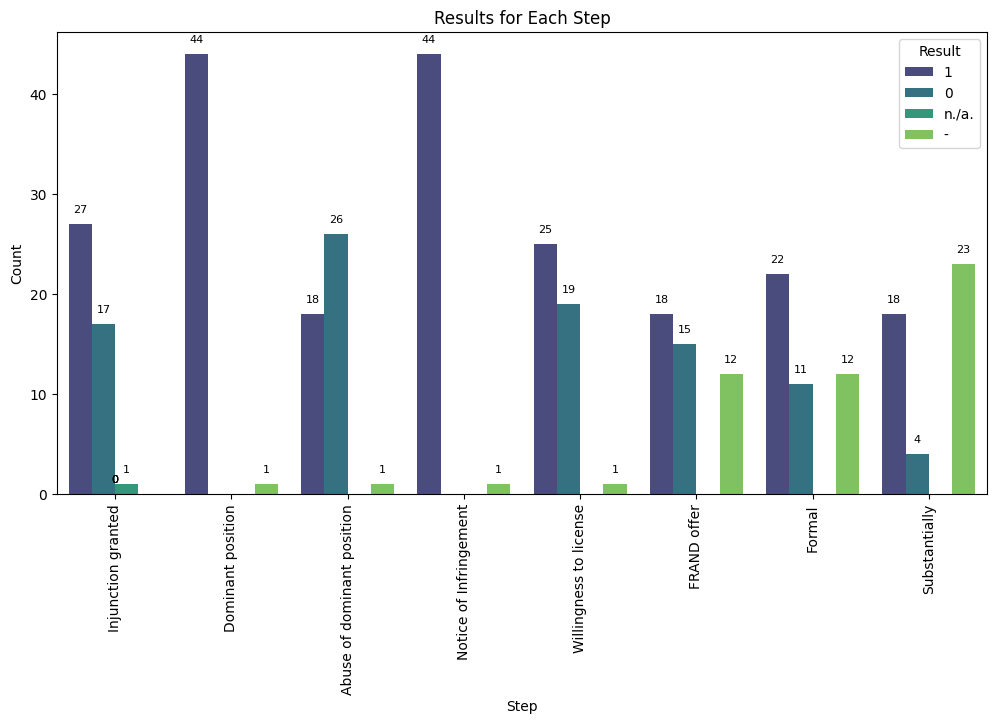

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read your Excel file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')

# Extract relevant columns for visualization
relevant_columns = ['Entscheidung (Untrelassung)', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']

# Subset the DataFrame with relevant columns
df_relevant = df[relevant_columns]
df_relevant = df_relevant.rename(columns={'Entscheidung (Untrelassung)': 'Injunction granted'})

# Convert 'Yes' to 1, 'No' to 0, and treat other values as 0 or 1 for calculating percentages
df_relevant.replace({'Yes': 1, 'No': 0, 'Yes*': 1, 'Yes?':1 , 'No?': 0, '?': 1}, inplace=True)

# Create a bar plot with specific categories for each step
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_relevant.melt(var_name='Step', value_name='Result'), x='Step', hue='Result', palette='viridis',
              order=['Injunction granted', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially'])
# Set vertical labels
plt.xticks(rotation=90)
plt.title('Results for Each Step')
plt.ylabel('Count')
# Add count values on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')

plt.show()

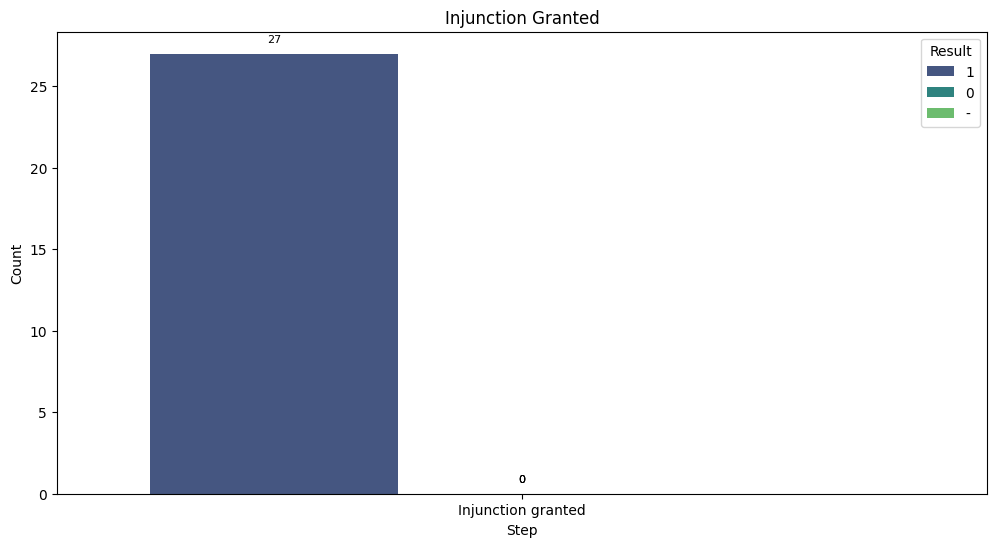

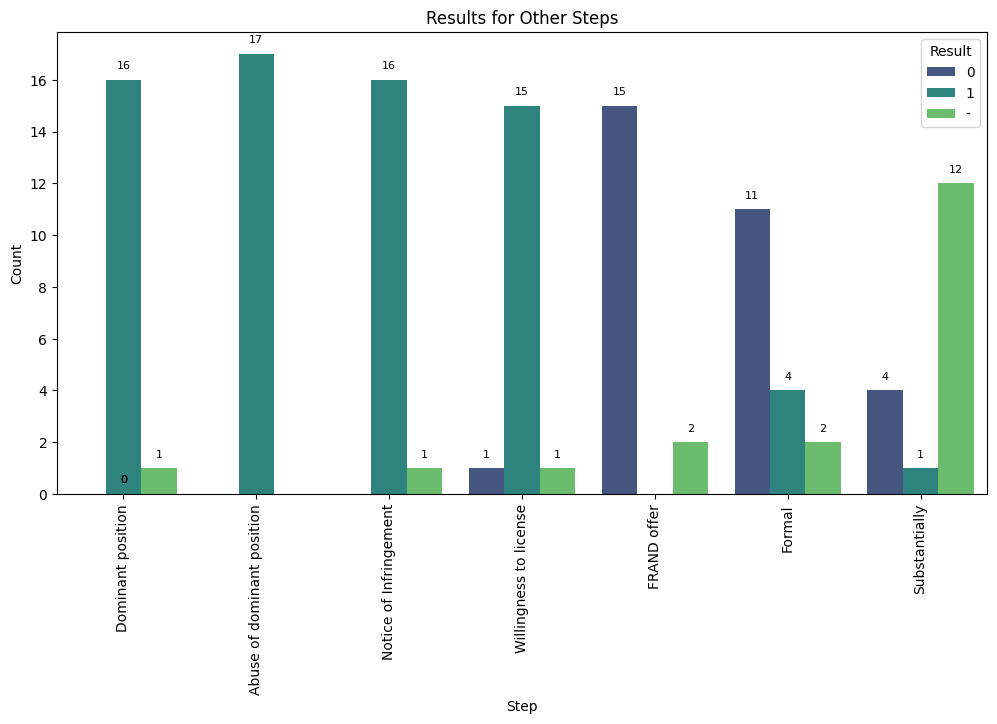

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read your Excel file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')

# Extract relevant columns for visualization
relevant_columns = ['Entscheidung (Untrelassung)', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']

# Subset the DataFrame with relevant columns
df_relevant = df[relevant_columns]
df_relevant = df_relevant.rename(columns={'Entscheidung (Untrelassung)': 'Injunction granted'})

# Convert 'Yes' to 1, 'No' to 0, and treat other values as 0 or 1 for calculating percentages
df_relevant.replace({'Yes': 1, 'No': 0, 'Yes*': 1, 'Yes?': 1, 'No?': 0, '?': 1}, inplace=True)

# Separate "Injunction granted" from other steps
df_injunction = df_relevant[df_relevant['Injunction granted'] == 1]
df_other_steps = df_relevant[df_relevant['Injunction granted'] == 0]

# Create a bar plot for "Injunction granted"
plt.figure(figsize=(12, 6))
ax_injunction = sns.countplot(data=df_injunction.melt(var_name='Step', value_name='Result'), x='Step', hue='Result', palette='viridis',
                              order=['Injunction granted'])
plt.title('Injunction Granted')
plt.ylabel('Count')

# Add count values on top of each bar
for p in ax_injunction.patches:
    ax_injunction.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                           xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')
# Remove zero at the middle of the first occurring value
ax_injunction.set_xlim(-0.5, len(df_other_steps['Injunction granted'].unique()) - 0.5)

plt.show()

# Create a bar plot for other steps
plt.figure(figsize=(12, 6))
ax_other_steps = sns.countplot(data=df_other_steps.melt(var_name='Step', value_name='Result'), x='Step', hue='Result', palette='viridis',
                               order=['Dominant position', 'Abuse of dominant position',
                                      'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially'])
# Set vertical labels
plt.xticks(rotation=90)
plt.title('Results for Other Steps')
plt.ylabel('Count')

# Add count values on top of each bar
for p in ax_other_steps.patches:
    ax_other_steps.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                            xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')

plt.show()


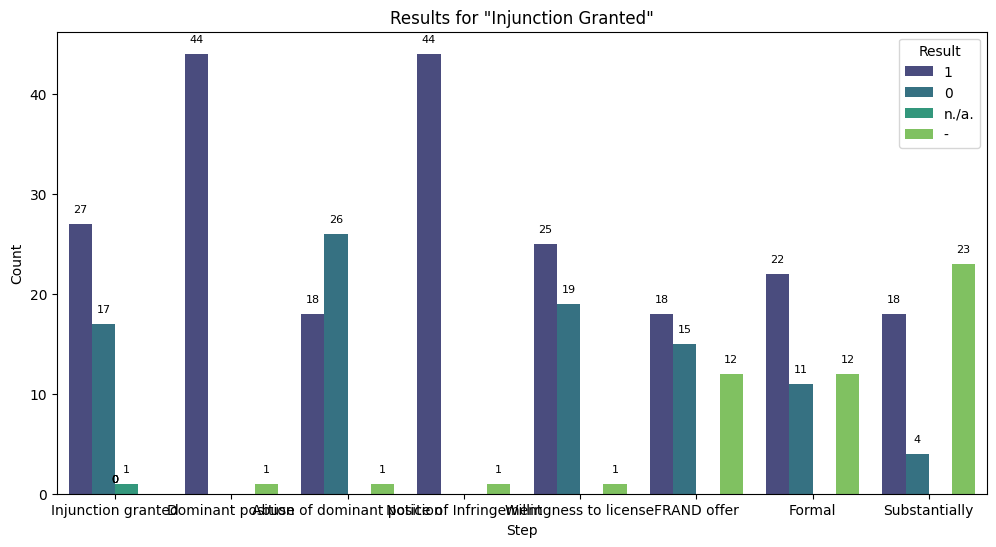

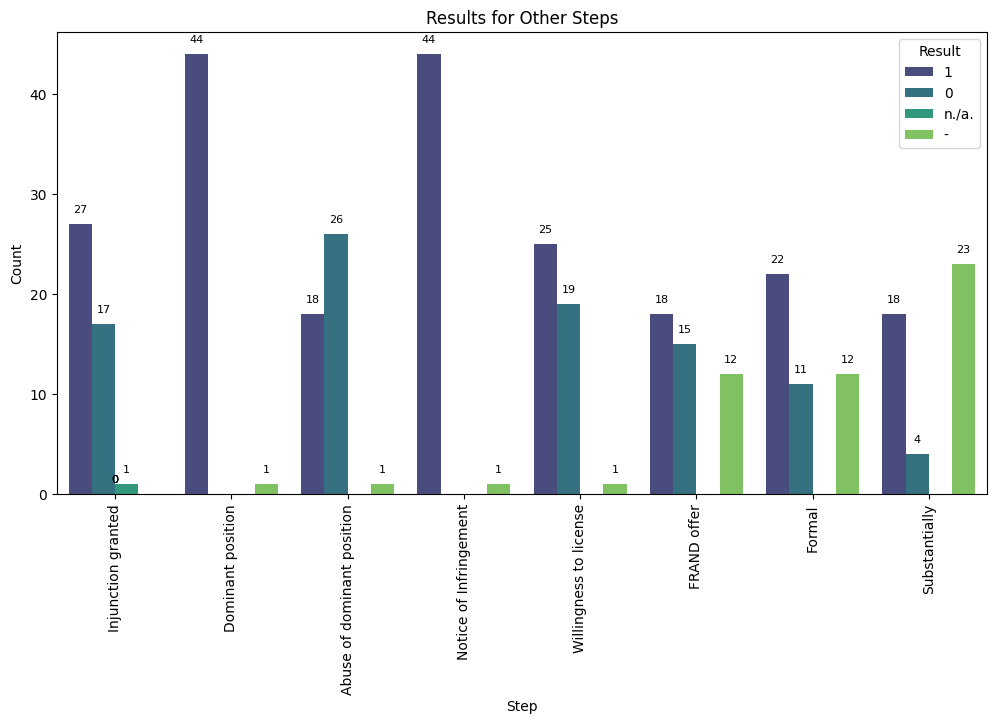

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read your Excel file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')

# Extract relevant columns for visualization
relevant_columns = ['Entscheidung (Untrelassung)', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']

# Subset the DataFrame with relevant columns
df_relevant = df[relevant_columns]
df_relevant = df_relevant.rename(columns={'Entscheidung (Untrelassung)': 'Injunction granted'})

# Convert 'Yes' to 1, 'No' to 0, and treat other values as 0 or 1 for calculating percentages
df_relevant.replace({'Yes': 1, 'No': 0, 'Yes*': 1, 'Yes?': 1, 'No?': 0, '?': 1}, inplace=True)

# Separate "Injunction granted" into its own table with all three results (1, 0, n./a.)
df_injunction = df_relevant[df_relevant['Injunction granted'].isin([1, 0, 'n./a.'])]

# Create a bar plot for "Injunction granted"
plt.figure(figsize=(12, 6))
ax_injunction = sns.countplot(data=df_injunction.melt(var_name='Step', value_name='Result'),
                              x='Step', hue='Result', palette='viridis',
                              order=['Injunction granted', 'Dominant position', 'Abuse of dominant position',
                                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially'])
plt.title('Results for "Injunction Granted"')
plt.ylabel('Count')

# Add count values on top of each bar
for p in ax_injunction.patches:
    ax_injunction.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                           xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')

plt.show()

# Create a bar plot for other steps
plt.figure(figsize=(12, 6))
ax_other_steps = sns.countplot(data=df_relevant.melt(var_name='Step', value_name='Result'),
                               x='Step', hue='Result', palette='viridis',
                               order=['Injunction granted', 'Dominant position', 'Abuse of dominant position',
                                      'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially'])
# Set vertical labels
plt.xticks(rotation=90)
plt.title('Results for Other Steps')
plt.ylabel('Count')

# Add count values on top of each bar
for p in ax_other_steps.patches:
    ax_other_steps.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                            xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')

plt.show()


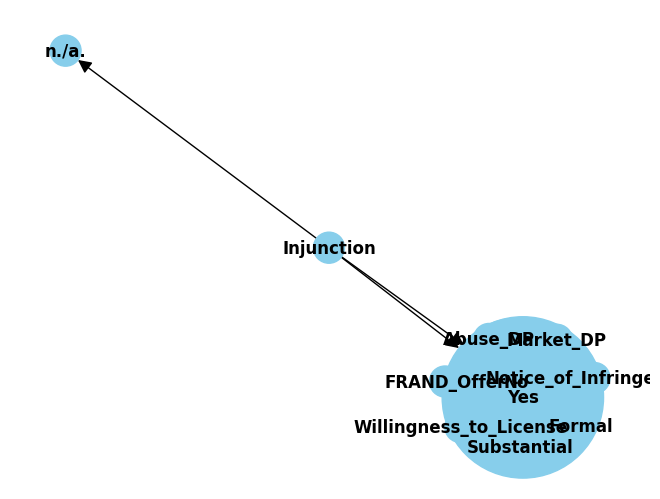

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Read your Excel file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges based on the decision tree structure
edges = [
    ('Injunction', 'Yes'), ('Injunction', 'No'), ('Injunction', 'n./a.'),
    ('Yes', 'Market_DP'), ('No', 'Market_DP'), ('Market_DP', 'Yes'), ('Market_DP', 'No'),
    ('Yes', 'Abuse_DP'), ('No', 'Abuse_DP'), ('Abuse_DP', 'Yes'), ('Abuse_DP', 'No'),
    ('Yes', 'Notice_of_Infringement'), ('No', 'Notice_of_Infringement'), ('Notice_of_Infringement', 'Yes'), ('Notice_of_Infringement', 'No'),
    ('Yes', 'Willingness_to_License'), ('No', 'Willingness_to_License'), ('Willingness_to_License', 'Yes'), ('Willingness_to_License', 'No'),
    ('Yes', 'FRAND_Offer'), ('No', 'FRAND_Offer'), ('FRAND_Offer', 'Yes'), ('FRAND_Offer', 'No'),
    ('Yes', 'Formal'), ('No', 'Formal'), ('Formal', 'Yes'), ('Formal', 'No'),
    ('Yes', 'Substantial'), ('No', 'Substantial'), ('Substantial', 'Yes'), ('Substantial', 'No'),
]

G.add_edges_from(edges)

# Get node frequencies
node_frequencies = df['Entscheidung (Untrelassung)'].value_counts().to_dict()

# Set node sizes based on frequencies
node_sizes = [node_frequencies.get(node, 1) * 500 for node in G.nodes]

# Draw the graph with static node positions and variable node sizes
pos = nx.spring_layout(G, seed=42)  # You can set a seed for static positions
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=node_sizes, node_color='skyblue', font_color='black', arrowsize=20)

plt.show()


Summary Statistics and Frequency Tables:

In [12]:
import pandas as pd
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')
# df.head()
df = df.rename(columns={'Entscheidung (Untrelassung)': 'Injunction'})
selected_columns = ['Aktenzeichen', 'Landgericht', 'Die Beklagte wird verurteilt zu unterlassen',
                    'Klage auf Unterlassung', 'Urteil', 'Prehuawei', 'First contact',
                    'Date of complaint', 'First licensing offer', 'Date of decision',
                    'Injunction', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially',
                     'Pool', 'Worldwide', 'Further proceedings']
df_sub = df.loc[:, selected_columns]

frand_defense = ['Injunction', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']
summary_stats = df_sub[frand_defense].describe(include='all').transpose()
print(summary_stats)

for column in df_sub.columns:
    if column != 'Injunction':
        freq_table = pd.crosstab(df_sub[column], df_sub['Injunction'], margins=True, margins_name='Total')
        print(f"\nFrequency Table for {column}:\n{freq_table}\n")


                           count unique  top freq
Injunction                    45      3  Yes   27
Dominant position             45      3  Yes   40
Abuse of dominant position    45      6   No   24
Notice of Infringement        45      3  Yes   43
Willingness to license        45      5  Yes   24
FRAND offer                   45      5   No   15
Formal                        45      7    -   12
Substantially                 45      6    -   23

Frequency Table for Aktenzeichen:
Injunction     No  Yes  n./a.  Total
Aktenzeichen                        
14d O 13/17     1    0      0      1
2 O 106/14      0    1      0      1
2 O 131/19      0    1      0      1
2 O 136/18      1    0      0      1
2 O 34/19       0    1      0      1
2 O 75/21       0    1      0      1
2 O 98/16       1    0      0      1
21 O 11522/21   0    1      0      1
21 O 1910/22    0    1      0      1
21 O 4140/21    0    1      0      1
4a O 126/14     0    1      0      1
4a O 144/14     0    1      0     

Bar charts

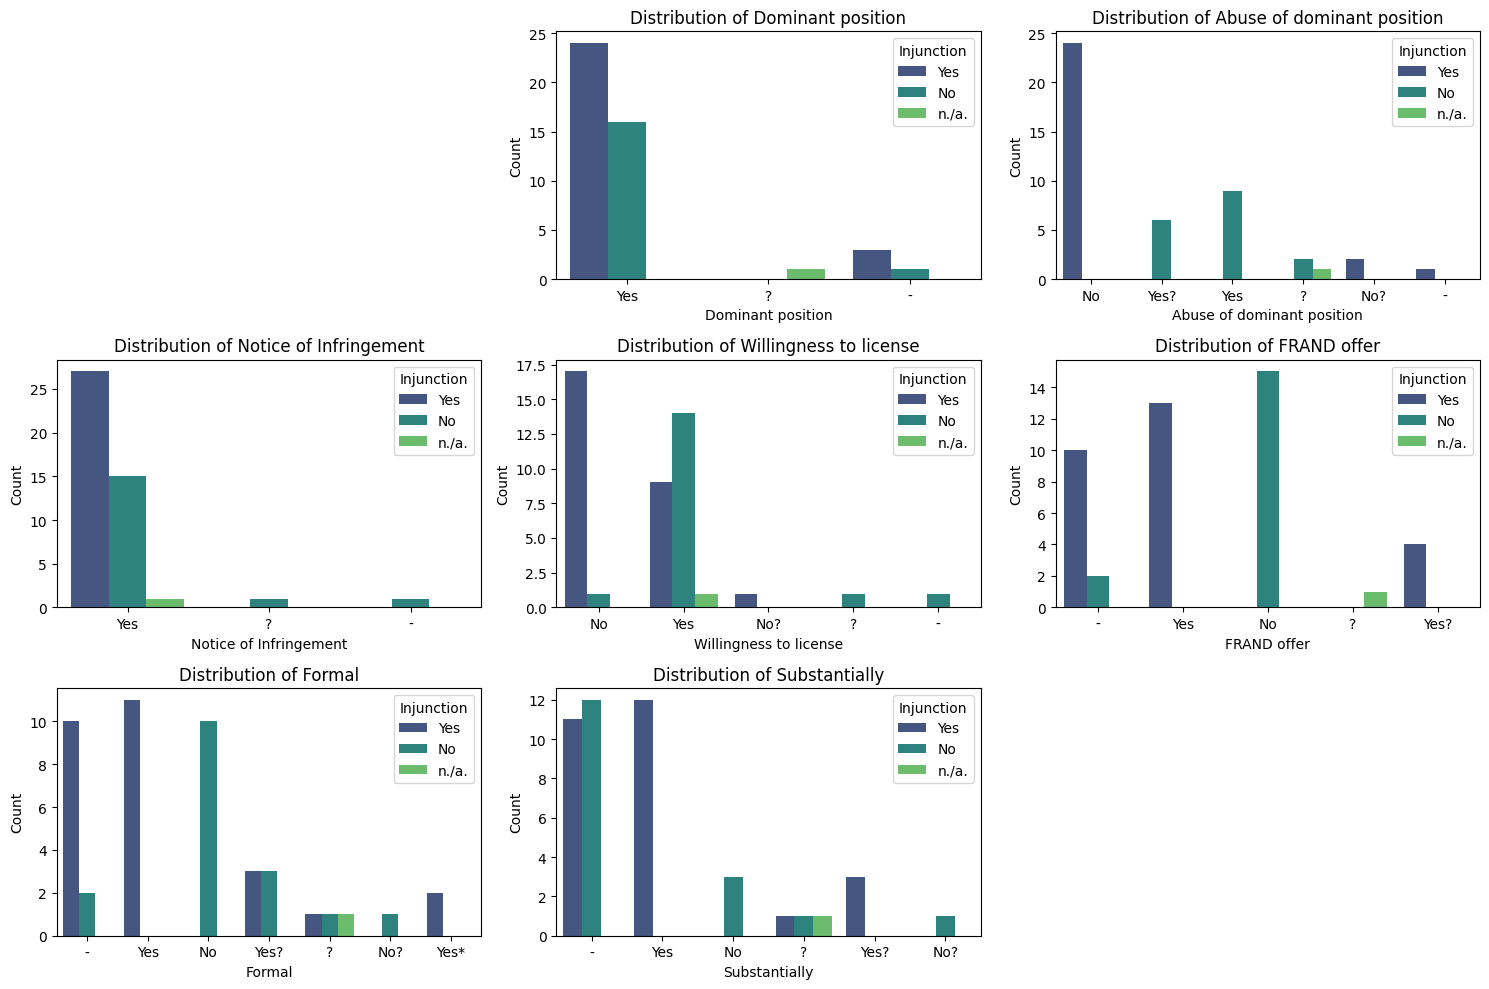

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df_frand_def = df_sub.loc[:, frand_defense]

plt.figure(figsize=(15, 10))
for i, column in enumerate(df_frand_def.columns):
    if column != 'Injunction':
        plt.subplot(3, 3, i + 1)
        sns.countplot(x=column, hue='Injunction', data=df, palette='viridis')
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
plt.tight_layout()
plt.show()


Correlation Heatmap

In [17]:
# Convert categorical columns to numeric representations
df_numeric = df_frand_def.apply(lambda x: x.astype('category').cat.codes) #FIND A BETTER WAY TO CONVERT THEM TO NUMBERS

df_numeric.head()

# Create a correlation heatmap with the numeric DataFrame
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()



,Injunction,Dominant position,Abuse of dominant position,Notice of Infringement,Willingness to license,FRAND offer,Formal,Substantially
0,1,2,2,2,2,0,0,0
1,1,2,2,2,2,3,4,4
2,1,2,2,2,2,3,4,4
3,0,2,5,2,4,2,2,0
4,0,2,5,2,4,2,2,0


Cross-Tabulation

In [19]:
for column in df_frand_def.columns:
    if column != 'Injunction':
        cross_tab = pd.crosstab(index=df_frand_def[column], columns=df_frand_def['Injunction'], margins=True, margins_name='Total')
        print(f"\nCross-Tabulation for {column}:\n{cross_tab}\n")



Cross-Tabulation for Dominant position:
Injunction         No  Yes  n./a.  Total
Dominant position                       
-                   1    3      0      4
?                   0    0      1      1
Yes                16   24      0     40
Total              17   27      1     45


Cross-Tabulation for Abuse of dominant position:
Injunction                  No  Yes  n./a.  Total
Abuse of dominant position                       
-                            0    1      0      1
?                            2    0      1      3
No                           0   24      0     24
No?                          0    2      0      2
Yes                          9    0      0      9
Yes?                         6    0      0      6
Total                       17   27      1     45


Cross-Tabulation for Notice of Infringement:
Injunction              No  Yes  n./a.  Total
Notice of Infringement                       
-                        1    0      0      1
?                        1 

Chi-Square test

In [22]:
from scipy.stats import chi2_contingency

# Loop through each variable
for variable in frand_defense[1:]:  # Exclude 'Injunction' from the loop
    # Create a contingency table
    contingency_table = pd.crosstab(df_frand_def[variable], df_frand_def['Injunction'])

    # Perform Chi-square test
    chi2, p, _, _ = chi2_contingency(contingency_table)

    # Print the results
    print(f"\nChi-square test for {variable} vs. Injunction:")
    print(f"Chi-square value: {chi2}")
    print(f"P-value: {p}")

    # Interpret the results
    if p < 0.05:
        print("There is a significant association.")
    else:
        print("There is no significant association.")


Chi-square test for Dominant position vs. Injunction:
Chi-square value: 45.35294117647058
P-value: 3.357769793009003e-09
There is a significant association.

Chi-square test for Abuse of dominant position vs. Injunction:
Chi-square value: 58.23529411764706
P-value: 7.806093995770997e-09
There is a significant association.

Chi-square test for Notice of Infringement vs. Injunction:
Chi-square value: 3.447332421340629
P-value: 0.48593161913180527
There is no significant association.

Chi-square test for Willingness to license vs. Injunction:
Chi-square value: 17.984749455337695
P-value: 0.021341112921800656
There is a significant association.

Chi-square test for FRAND offer vs. Injunction:
Chi-square value: 82.81045751633985
P-value: 1.3267219807621569e-14
There is a significant association.

Chi-square test for Formal vs. Injunction:
Chi-square value: 43.464052287581694
P-value: 1.8837971696020602e-05
There is a significant association.

Chi-square test for Substantially vs. Injunctio

Flow Chart